# Plot-genre annotations across the rise of the novel

Sonnet's `plot_genre` annotation task (1,452 texts, 1500-2000) tags each text along six axes derived from Frye, Pavel, and standard plot-typology:

- **mythos**: comedy / romance / tragedy / irony_satire (Frye's four mythoi)
- **frye_mode**: myth / romance / high_mimetic / low_mimetic / ironic (descending hero-power)
- **pavel_tradition**: idealist / anti_idealist / novella / synthesis (Pavel's *Lives of the Novel*)
- **moral_source**: transcendent / immanent / contextual / aesthetic / absent
- **plot_structure**: episodic / unified / bildungsroman / frame_tale
- **ending_type**: marriage / death / reform / return / open / ambiguous

Joined to per-text social-network metrics from §15 to test whether plot category and network structure correlate.

Companion notebook: `17-subgenre.ipynb`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
from collections import Counter
from lltk.annotate import iter_task_results

plt.rcParams['figure.dpi'] = 110

DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

# Per-text network metrics
df_net = pd.read_csv('../data/social_networks/social_network_analysis.csv')

# plot_genre annotations
rows = []
for _id, d in iter_task_results('plot_genre'):
    row = {'source': _id}
    for k in ('mythos', 'frye_mode', 'pavel_tradition', 'moral_source',
             'plot_structure', 'ending_type'):
        row[k] = d.get(k)
    rows.append(row)
pg = pd.DataFrame(rows)

# Merge: keep all plot_genre rows; bring in year + network metrics where available
df = pg.merge(df_net, on='source', how='left')
print(f'plot_genre rows: {len(pg):,}')
print(f'  with year:      {df["year"].notna().sum():,}')
print(f'  with net metrics (n_chars set): {df["n_chars"].notna().sum():,}')
df.head(3)

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


plot_genre rows: 1,452
  with year:      1,393
  with net metrics (n_chars set): 1,393


,source,mythos,frye_mode,pavel_tradition,moral_source,plot_structure,ending_type,year,id,title,...,comp_clustering_resid,comp_centralization_resid,comp_degree_gini_resid,comp_reciprocity_resid,comp_assortativity_resid,rel_density_resid,rel_clustering_resid,rel_reciprocity_resid,dial_reciprocity_resid,evt_centralization_resid
0,_chadwyck/Early_English_Prose_Fiction/ee01010.01,irony_satire,low_mimetic,anti_idealist,contextual,unified,open,1699.0,ee01010.01,The Adventures of Covent&hyphen;Garden (1699),...,-0.073260,-0.191546,0.016488,0.255461,-0.037316,0.100159,-0.259329,0.600612,0.012084,0.008014
1,_chadwyck/Early_English_Prose_Fiction/ee01010.02,irony_satire,low_mimetic,anti_idealist,contextual,frame_tale,ambiguous,1696.0,ee01010.02,Alcander and Philocrates (1696),...,-0.056385,-0.037174,-0.027450,0.062547,0.199792,-0.027328,0.037813,0.186612,-0.004869,-0.020669
2,_chadwyck/Early_English_Prose_Fiction/ee01010.03,irony_satire,low_mimetic,anti_idealist,contextual,episodic,open,1663.0,ee01010.03,The Case of Madam Mary Carlton (1663),...,-0.258026,-0.031190,0.118935,-0.204069,0.088759,-0.038114,-0.168953,-0.008466,-0.090671,-0.117862


## 1. Distribution of each axis

In [2]:
FIELDS = ['mythos', 'frye_mode', 'pavel_tradition',
          'moral_source', 'plot_structure', 'ending_type']
for f in FIELDS:
    print(f'== {f} ==')
    print(df[f].value_counts(dropna=False).to_string())
    print()

== mythos ==
mythos
irony_satire    473
romance         429
comedy          282
tragedy         268

== frye_mode ==
frye_mode
low_mimetic     849
romance         253
high_mimetic    214
ironic          125
myth             11

== pavel_tradition ==
pavel_tradition
anti_idealist    571
idealist         550
synthesis        324
novella            7

== moral_source ==
moral_source
contextual      567
transcendent    454
immanent        249
absent          164
aesthetic        18

== plot_structure ==
plot_structure
episodic         767
unified          452
bildungsroman    129
frame_tale       104

== ending_type ==
ending_type
open         439
marriage     359
death        303
ambiguous    214
return        98
reform        39



## 2. Diachronic trends — proportion of each category over time

Decade-binned proportion of texts in each category, faceted by axis. Free y-scales per panel.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/plot_genre_diachronic_25y.png


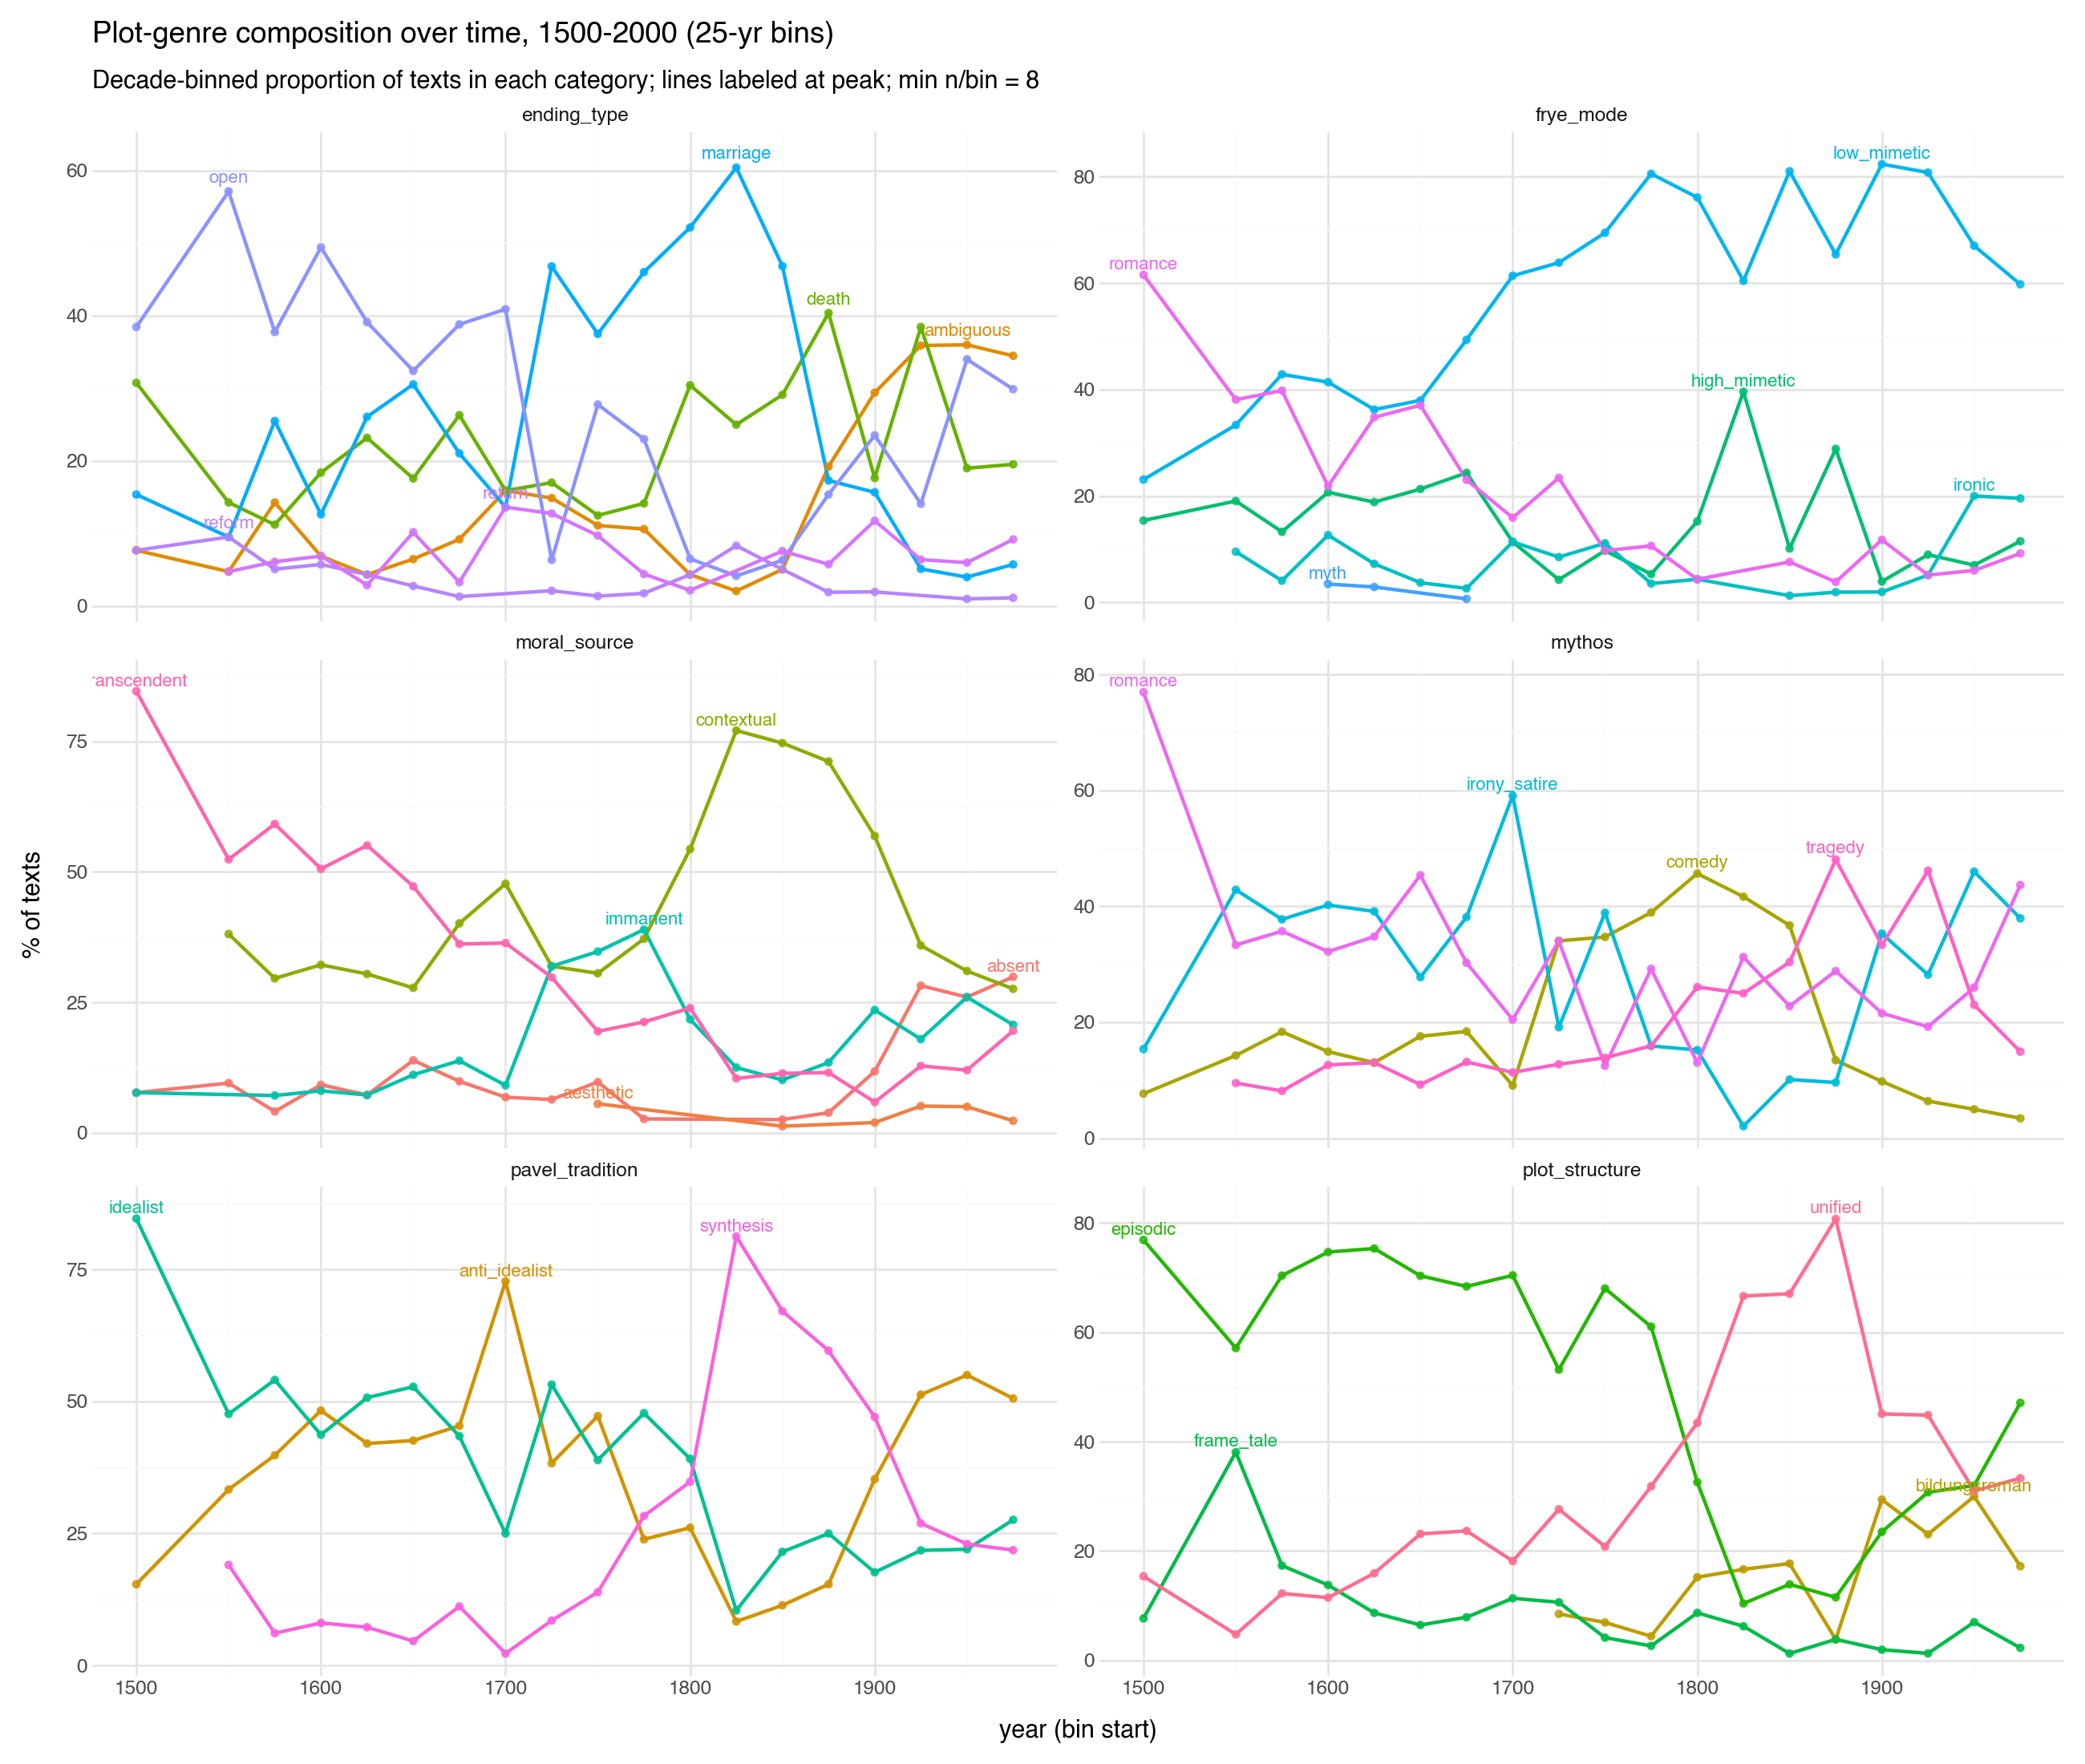

In [3]:
DECADE = 25  # 25-year bins (smoother than decade)
MIN_N = 8

dia = df[(df['year'] >= 1500) & (df['year'] < 2000)].copy()
dia['bin'] = (dia['year'] // DECADE * DECADE).astype(int)

long_rows = []
for f in FIELDS:
    grouped = dia.groupby(['bin', f]).size().reset_index(name='n')
    bin_totals = grouped.groupby('bin')['n'].sum().rename('total')
    grouped = grouped.merge(bin_totals, on='bin')
    grouped = grouped[grouped['total'] >= MIN_N].copy()
    grouped['pct'] = grouped['n'] / grouped['total'] * 100
    grouped['axis'] = f
    grouped = grouped.rename(columns={f: 'category'})
    long_rows.append(grouped[['bin', 'axis', 'category', 'pct', 'n', 'total']])
diachronic = pd.concat(long_rows, ignore_index=True)
diachronic = diachronic.dropna(subset=['category'])

# One label per (axis, category) at the bin where pct peaks.
peak_rows = (diachronic.sort_values('pct', ascending=False)
             .groupby(['axis', 'category'], as_index=False)
             .first())

p_dia = (p9.ggplot(diachronic, p9.aes(x='bin', y='pct', color='category'))
         + p9.geom_line(size=0.9)
         + p9.geom_point(size=1.2, alpha=0.8)
         + p9.geom_text(p9.aes(label='category'),
                        data=peak_rows,
                        nudge_y=1.8, size=8, fontweight='bold',
                        show_legend=False)
         + p9.facet_wrap('~ axis', ncol=2, scales='free_y')
         + p9.scale_x_continuous(breaks=range(1500, 2001, 100))
         + p9.labs(
             title=f'Plot-genre composition over time, 1500-2000 ({DECADE}-yr bins)',
             subtitle=f'Decade-binned proportion of texts in each category; lines labeled at peak; min n/bin = {MIN_N}',
             x='year (bin start)', y='% of texts',
             color='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(13, 11),
                    legend_position='none'))

out = os.path.join(DROPBOX_FIGS, 'plot_genre_diachronic_25y.png')
p_dia.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_dia

## 3. Pavel's idealist / anti-idealist axis (close-up)

Pavel argues that the novel is the *anti-idealist* descendant of idealist romance — and that the C18 sentimental novel is a synthesis. This plot tracks all four Pavel categories as a stacked-line view.

Look for the inflection: when do anti_idealist and synthesis overtake idealist?

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/plot_genre_pavel_25y.png


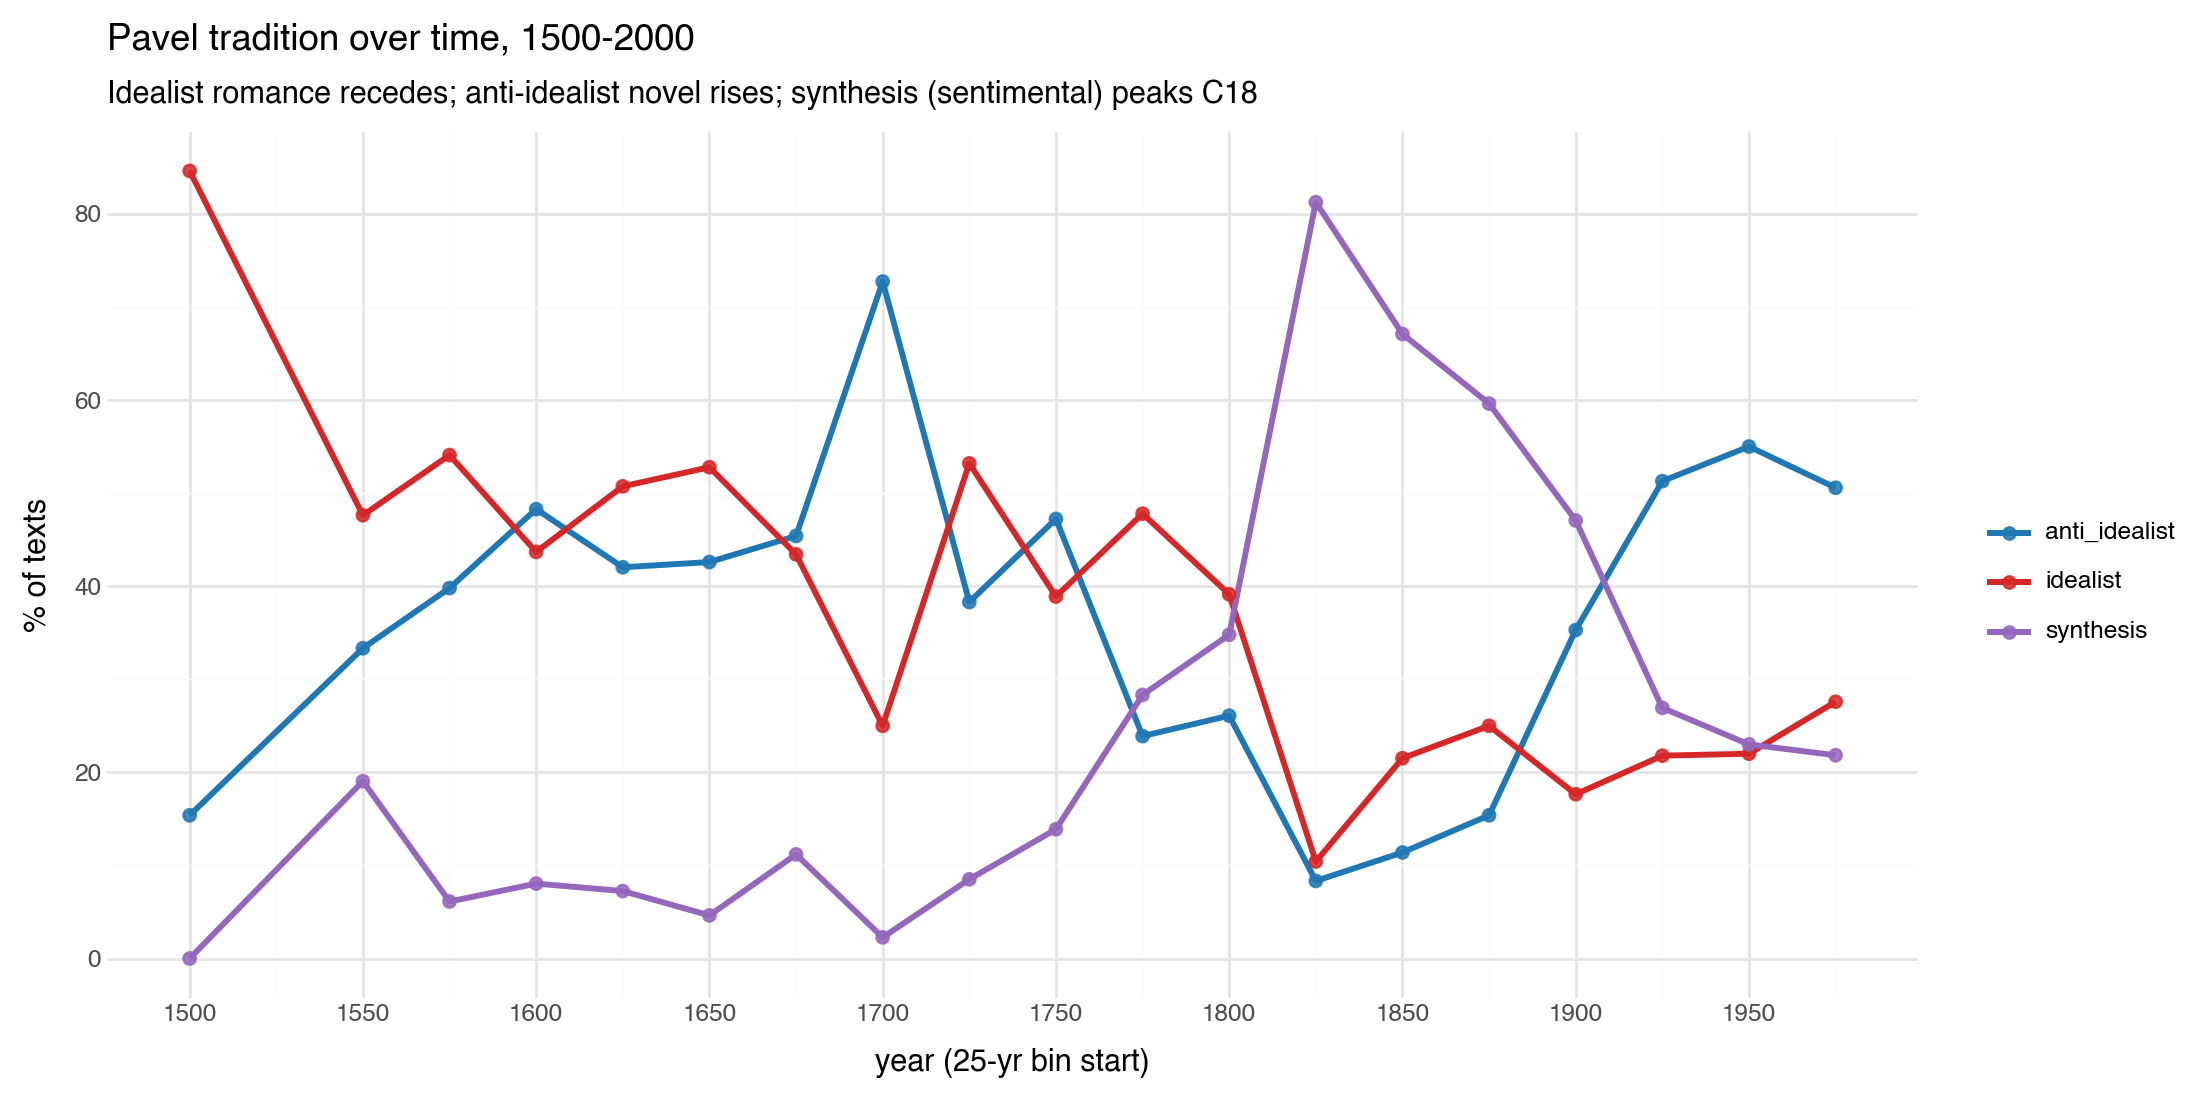

In [4]:
pav = (diachronic[diachronic['axis'] == 'pavel_tradition']
       .pivot(index='bin', columns='category', values='pct')
       .fillna(0).reset_index())
pav_long = pav.melt(id_vars='bin', var_name='category', value_name='pct')

p_pav = (p9.ggplot(pav_long, p9.aes(x='bin', y='pct', color='category'))
         + p9.geom_line(size=1.2)
         + p9.geom_point(size=2, alpha=0.85)
         + p9.scale_x_continuous(breaks=range(1500, 2001, 50))
         + p9.scale_color_manual(values={
             'idealist': '#d62728',       # red - the romance tradition
             'anti_idealist': '#1f77b4',  # blue - the novel proper
             'synthesis': '#9467bd',      # purple - C18 sentimental
             'novella': '#2ca02c',        # green - the short form
         })
         + p9.labs(
             title='Pavel tradition over time, 1500-2000',
             subtitle='Idealist romance recedes; anti-idealist novel rises; synthesis (sentimental) peaks C18',
             x='year (25-yr bin start)', y='% of texts',
             color='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(11, 5.5)))

out = os.path.join(DROPBOX_FIGS, 'plot_genre_pavel_25y.png')
p_pav.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_pav

## 4. Cross-tabulation with social-network metrics

For each plot-genre axis, group on category and report mean network metrics. Tests whether structural network features track genre categories — e.g. does *comedy* show higher reciprocity (knowable community), does *anti_idealist* show lower clustering (atomized social fabric)?

Restricted to texts with non-null network metrics (n_chars set).

In [5]:
METRICS = ['n_chars', 'n_rels', 'comp_density', 'comp_clustering',
           'comp_reciprocity', 'comp_centralization', 'comp_degree_gini',
           'comp_assortativity', 'female_pct', 'char_desc_conc']

valid = df[df['n_chars'].notna()].copy()
print(f'{len(valid):,} texts with both plot_genre and network metrics')

for f in FIELDS:
    means = (valid.groupby(f)[METRICS]
             .agg(['count', 'mean'])
             .round(3))
    print(f'\n=== {f} ===')
    # flatten: keep ('count' once + every metric mean)
    n_per_cat = valid.groupby(f).size().rename('n')
    metric_means = valid.groupby(f)[METRICS].mean().round(3)
    out = pd.concat([n_per_cat, metric_means], axis=1)
    print(out.to_string())

1,393 texts with both plot_genre and network metrics

=== mythos ===
                n  n_chars  n_rels  comp_density  comp_clustering  comp_reciprocity  comp_centralization  comp_degree_gini  comp_assortativity  female_pct  char_desc_conc
mythos                                                                                                                                                                    
comedy        276   54.641  95.196         0.081            0.294             0.486                0.327             0.482              -0.298      37.205          -0.257
irony_satire  429   71.103  74.755         0.054            0.187             0.394                0.317             0.507              -0.367      27.216          -0.127
romance       424   59.099  85.800         0.061            0.266             0.436                0.369             0.511              -0.347      25.959          -0.158
tragedy       264   49.242  88.345         0.073            0.303           

### Visualize: 4 selected metrics × 4 axes

Boxplots: pick the most diagnostic axes (mythos, pavel_tradition) × most diagnostic metrics (comp_reciprocity, comp_clustering, comp_density, char_desc_conc). Free y-scales.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/plot_genre_network_metrics_box.png


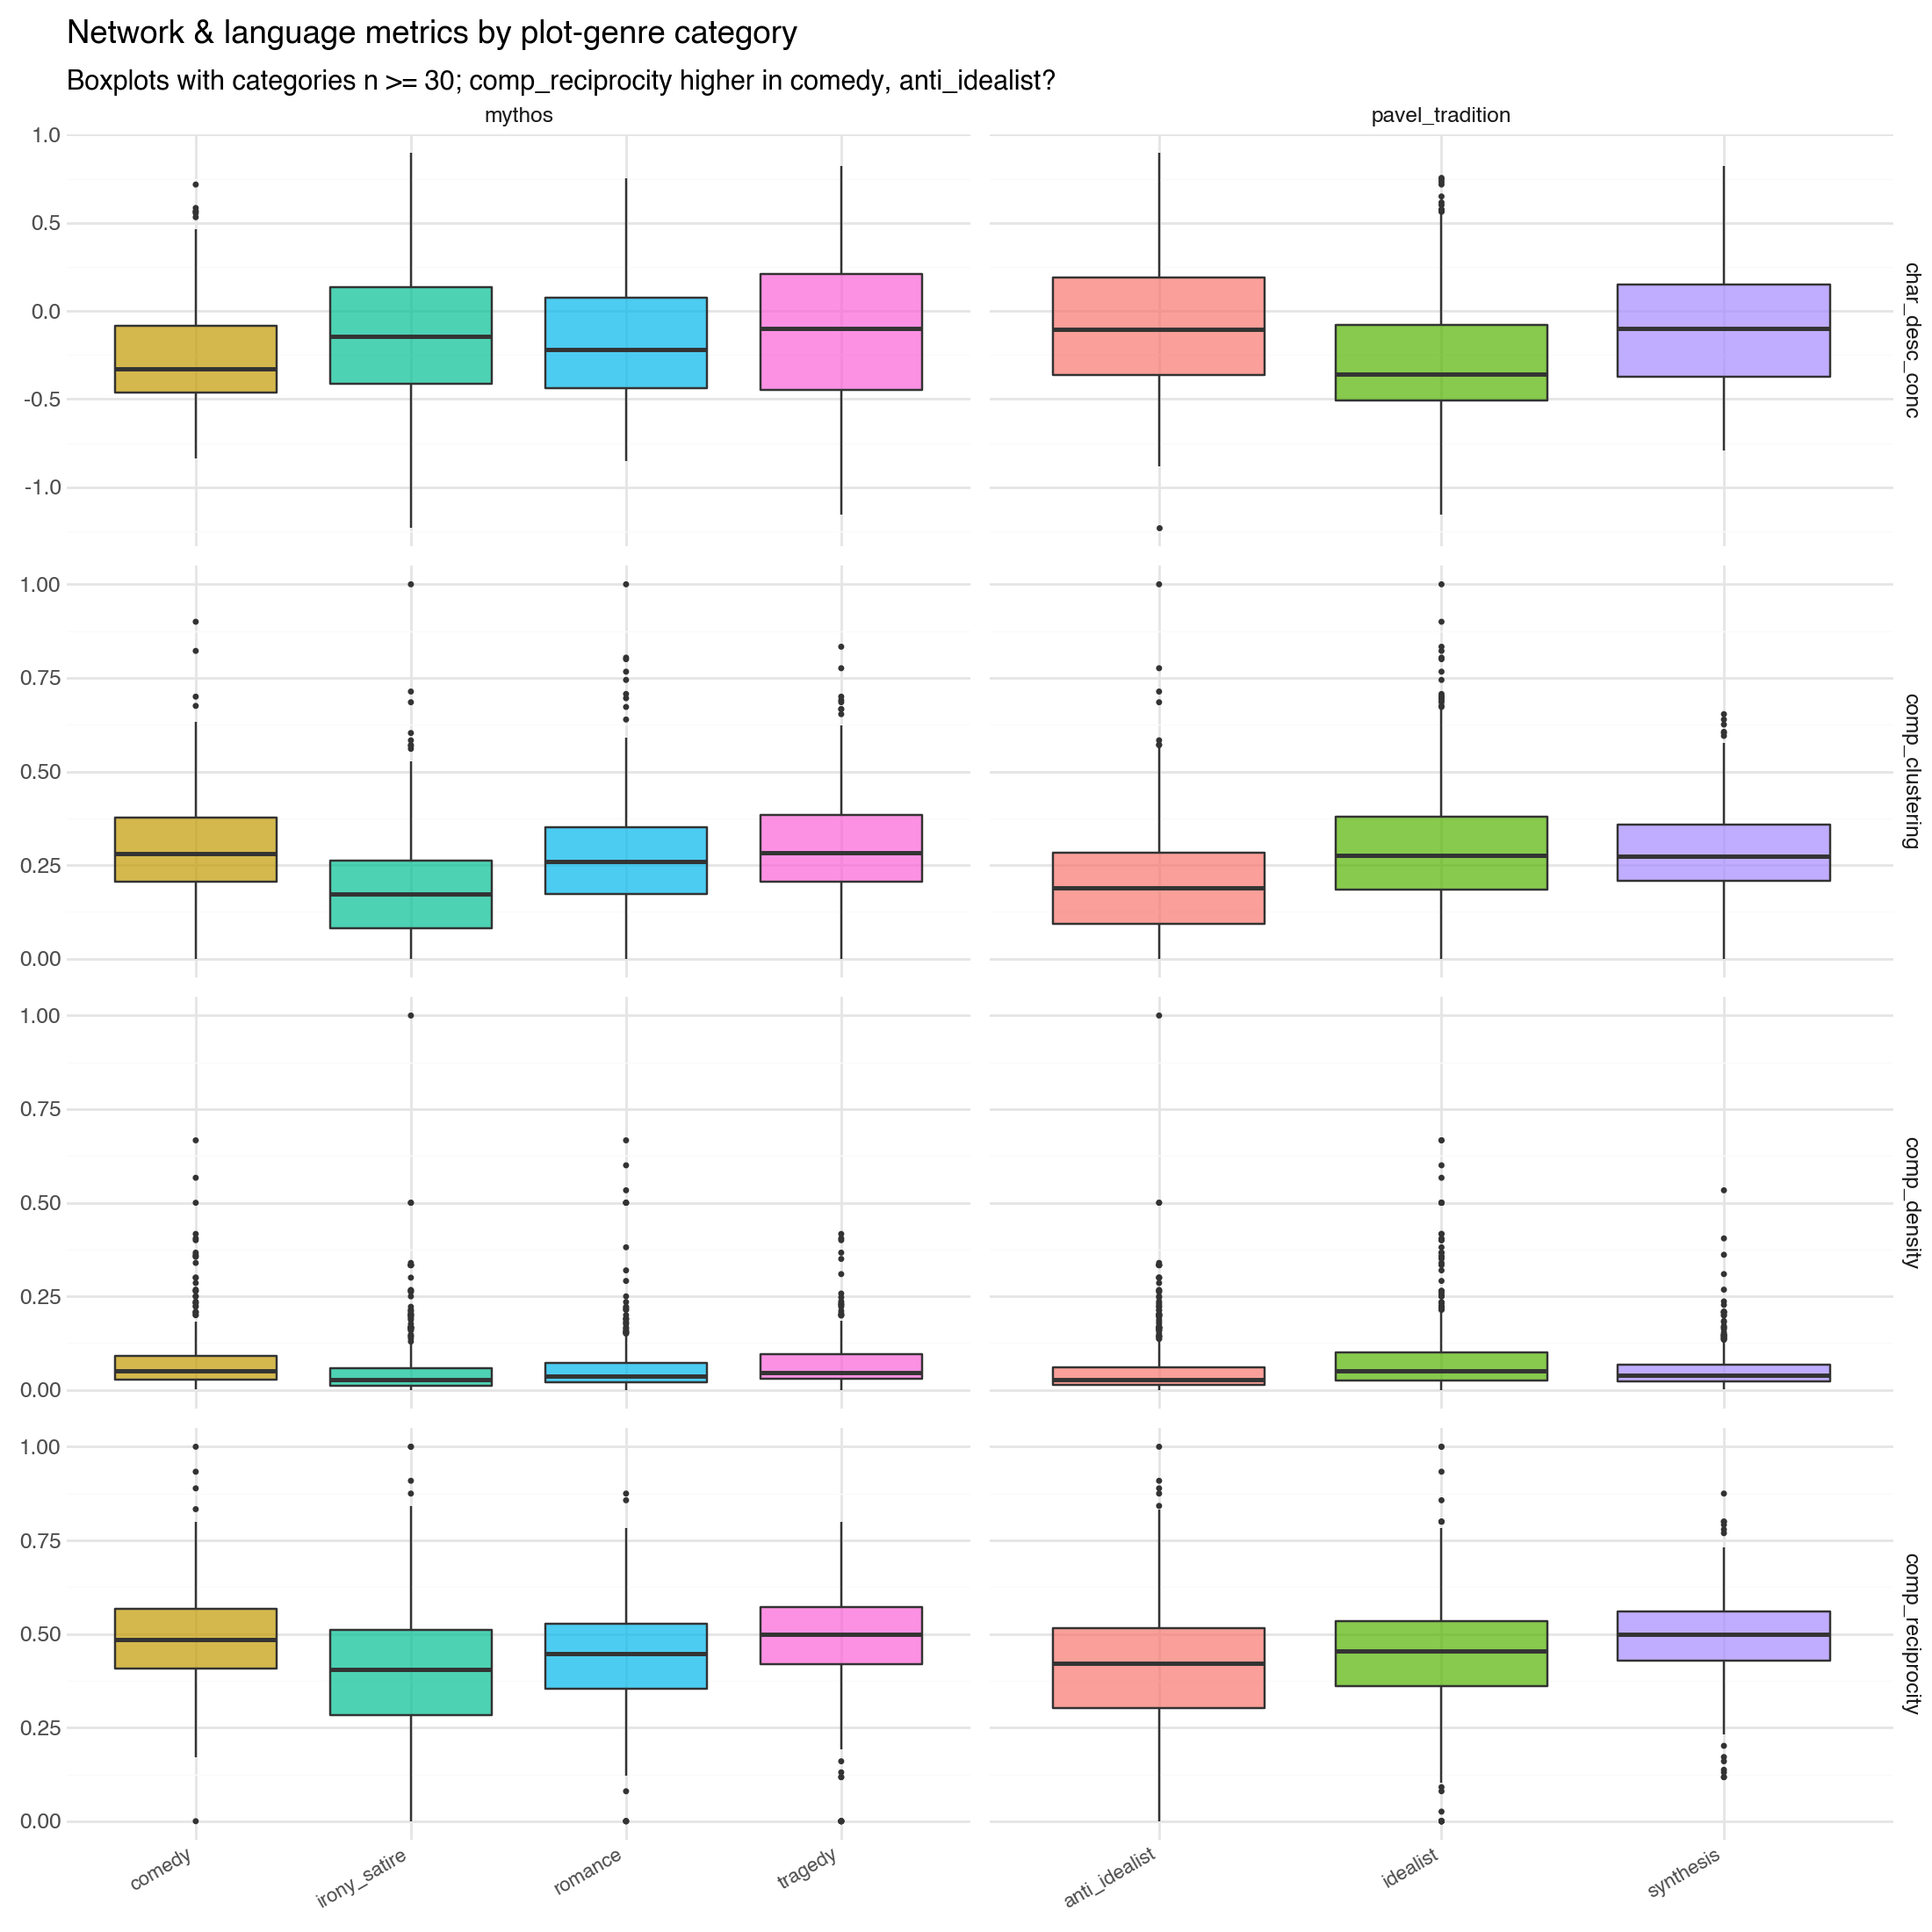

In [6]:
sel_axes = ['mythos', 'pavel_tradition']
sel_metrics = ['comp_reciprocity', 'comp_clustering', 'comp_density', 'char_desc_conc']

box_rows = []
for ax_field in sel_axes:
    for m in sel_metrics:
        sub = valid[[ax_field, m]].dropna().rename(columns={ax_field: 'category', m: 'value'})
        sub['axis'] = ax_field
        sub['metric'] = m
        box_rows.append(sub)
box_df = pd.concat(box_rows, ignore_index=True)

# Restrict to categories with >= 30 texts in the relevant axis (drop tail)
keep = box_df.groupby(['axis', 'category']).size().reset_index(name='n')
keep = keep[keep['n'] >= 30][['axis', 'category']]
box_df = box_df.merge(keep, on=['axis', 'category'])

p_box = (p9.ggplot(box_df, p9.aes(x='category', y='value', fill='category'))
         + p9.geom_boxplot(outlier_size=0.4, alpha=0.7)
         + p9.facet_grid('metric ~ axis', scales='free')
         + p9.labs(
             title='Network & language metrics by plot-genre category',
             subtitle='Boxplots with categories n >= 30; comp_reciprocity higher in comedy, anti_idealist?',
             x='', y='', fill='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(11, 11),
                    axis_text_x=p9.element_text(rotation=30, ha='right', size=8),
                    legend_position='none'))

out = os.path.join(DROPBOX_FIGS, 'plot_genre_network_metrics_box.png')
p_box.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_box

## 5. Cross with text-level abstractness

Pull whole-text abstractness from `abstraction.scores_en` and ask: do anti-idealist novels have higher abstractness than idealist romances? (Ch5's prediction: yes — anti-idealism aligns with the novel's reflective/internal narration.)

In [7]:
import clickhouse_connect
c = clickhouse_connect.get_client(host='localhost', port=8123,
                                  username='lltk', password='lltk')
ids = df['source'].dropna().unique().tolist()
sc = c.query_df(
    "SELECT _id, `Abs-Conc.Median.median` AS raw "
    "FROM abstraction.scores_en WHERE _id IN %(ids)s",
    parameters={'ids': ids},
).drop_duplicates('_id')
sc['abs_score'] = -sc['raw']
m = df.merge(sc[['_id', 'abs_score']], left_on='source', right_on='_id', how='left')
print(f'{m["abs_score"].notna().sum():,}/{len(m):,} texts with whole-text abstractness')

print('\nMean abstractness by Pavel tradition:')
print(m.groupby('pavel_tradition')['abs_score'].agg(['count', 'mean']).round(3))

print('\nMean abstractness by mythos:')
print(m.groupby('mythos')['abs_score'].agg(['count', 'mean']).round(3))

c.close()

1,452/1,452 texts with whole-text abstractness

Mean abstractness by Pavel tradition:
                 count   mean
pavel_tradition              
anti_idealist      571  0.212
idealist           550  0.342
novella              7  0.351
synthesis          324  0.297

Mean abstractness by mythos:
              count   mean
mythos                    
comedy          282  0.420
irony_satire    473  0.253
romance         429  0.239
tragedy         268  0.251


## 6. Abstractness decomposition — plot_genre vs. year

Same exercise as notebook 17 §5, but for the six plot_genre fields. Each text has exactly one value per field (single-label, unlike subgenre which is multi-label), so we one-hot the categorical fields and compare:

1. R² of `abs ~ year` alone
2. R² of `abs ~ field` for each of the 6 fields individually
3. R² of `abs ~ year + all 6 fields combined`

Plus a per-category coefficient plot (all six fields' dummies, color-coded by field, controlling for year).

Note: mythos / frye_mode / pavel_tradition overlap conceptually, so the joint model has some collinearity; we report individual-field R²s alongside the combined one.

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression

work = m[m['year'].notna() & m['abs_score'].notna()].copy()
n = len(work)
print(f'{n:,} texts with year + abstractness + plot_genre fields')

X_year = (work[['year']].values.astype(float) - work['year'].mean())
y = work['abs_score'].values

def fit_r2(X):
    return LinearRegression().fit(X, y).score(X, y)

def adj(r2_val, k):
    return 1 - (1 - r2_val) * (n - 1) / (n - k - 1)

def make_dummies(field):
    """get_dummies with most common category dropped as reference."""
    s = work[field].fillna('__missing__')
    dummies = pd.get_dummies(s, prefix=field).astype(float)
    # Drop the most common category as reference
    most_common = s.value_counts().index[0]
    ref_col = f'{field}_{most_common}'
    if ref_col in dummies.columns:
        dummies = dummies.drop(columns=[ref_col])
    return dummies, most_common, ref_col

print()
print(f'{"model":<40} {"k":>4} {"R^2":>8} {"adj R^2":>8}')
print('-' * 64)

# Year alone
r2_year = fit_r2(X_year)
print(f'{"year alone":<40} {1:>4} {r2_year:>8.4f} {adj(r2_year, 1):>8.4f}')

# Each field alone
field_r2 = {}
field_dummies = {}
for f in FIELDS:
    dum, ref, _ = make_dummies(f)
    field_dummies[f] = dum
    r = fit_r2(dum.values)
    field_r2[f] = r
    print(f'{"  " + f + " (ref=" + ref + ")":<40} {dum.shape[1]:>4} {r:>8.4f} {adj(r, dum.shape[1]):>8.4f}')

# All six fields combined
X_all = pd.concat(list(field_dummies.values()), axis=1).values
r2_all = fit_r2(X_all)
k_all = X_all.shape[1]
print(f'{"all 6 fields combined":<40} {k_all:>4} {r2_all:>8.4f} {adj(r2_all, k_all):>8.4f}')

# Year + all six
X_both = np.hstack([X_year, X_all])
r2_both = fit_r2(X_both)
print(f'{"year + all 6 fields":<40} {k_all+1:>4} {r2_both:>8.4f} {adj(r2_both, k_all+1):>8.4f}')

print()
print('--- Variance partition (year vs all-six combined) ---')
unique_year = r2_both - r2_all
unique_pg = r2_both - r2_year
shared = r2_year + r2_all - r2_both
print(f'  Unique to YEAR        = {unique_year:.4f}')
print(f'  Unique to PLOT_GENRE  = {unique_pg:.4f}')
print(f'  Shared (collinear)    = {shared:.4f}')
print(f'  Total explained       = {r2_both:.4f}')
ratio = unique_pg / unique_year if unique_year > 0 else float('inf')
print(f'  Plot_genre/year unique-effect ratio = {ratio:.2f}x')

1,393 texts with year + abstractness + plot_genre fields

model                                       k      R^2  adj R^2
----------------------------------------------------------------
year alone                                  1   0.1930   0.1924
  mythos (ref=irony_satire)                 3   0.0467   0.0447
  frye_mode (ref=low_mimetic)               4   0.0455   0.0428
  pavel_tradition (ref=anti_idealist)       2   0.0330   0.0316
  moral_source (ref=contextual)             4   0.0817   0.0790
  plot_structure (ref=episodic)             3   0.0177   0.0156
  ending_type (ref=open)                    5   0.0990   0.0957
all 6 fields combined                      21   0.2617   0.2504
year + all 6 fields                        22   0.3605   0.3503

--- Variance partition (year vs all-six combined) ---
  Unique to YEAR        = 0.0989
  Unique to PLOT_GENRE  = 0.1675
  Shared (collinear)    = 0.0942
  Total explained       = 0.3605
  Plot_genre/year unique-effect ratio = 1.69x


Year coef: -0.00100 per year (t = -14.55, p = 1.01e-44)

Plot-genre coefficients (effect on abstractness after detrending year):
          field      category      coef       se            p  signif
    ending_type        return -0.091212 0.031835 4.232319e-03    True
    ending_type        reform -0.056219 0.045104 2.128131e-01   False
    ending_type     ambiguous  0.000332 0.024221 9.890598e-01   False
    ending_type         death  0.011550 0.026608 6.643084e-01   False
    ending_type      marriage  0.158756 0.025031 3.066215e-10    True
      frye_mode       romance -0.086083 0.027858 2.041178e-03    True
      frye_mode        ironic  0.001583 0.032198 9.607914e-01   False
      frye_mode          myth  0.058648 0.110754 5.965210e-01   False
      frye_mode  high_mimetic  0.097880 0.024028 4.893822e-05    True
   moral_source        absent -0.153270 0.028232 6.698807e-08    True
   moral_source     aesthetic -0.058414 0.066791 3.819593e-01   False
   moral_source  transcendent  


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/plot_genre_abstractness_coefficients.png


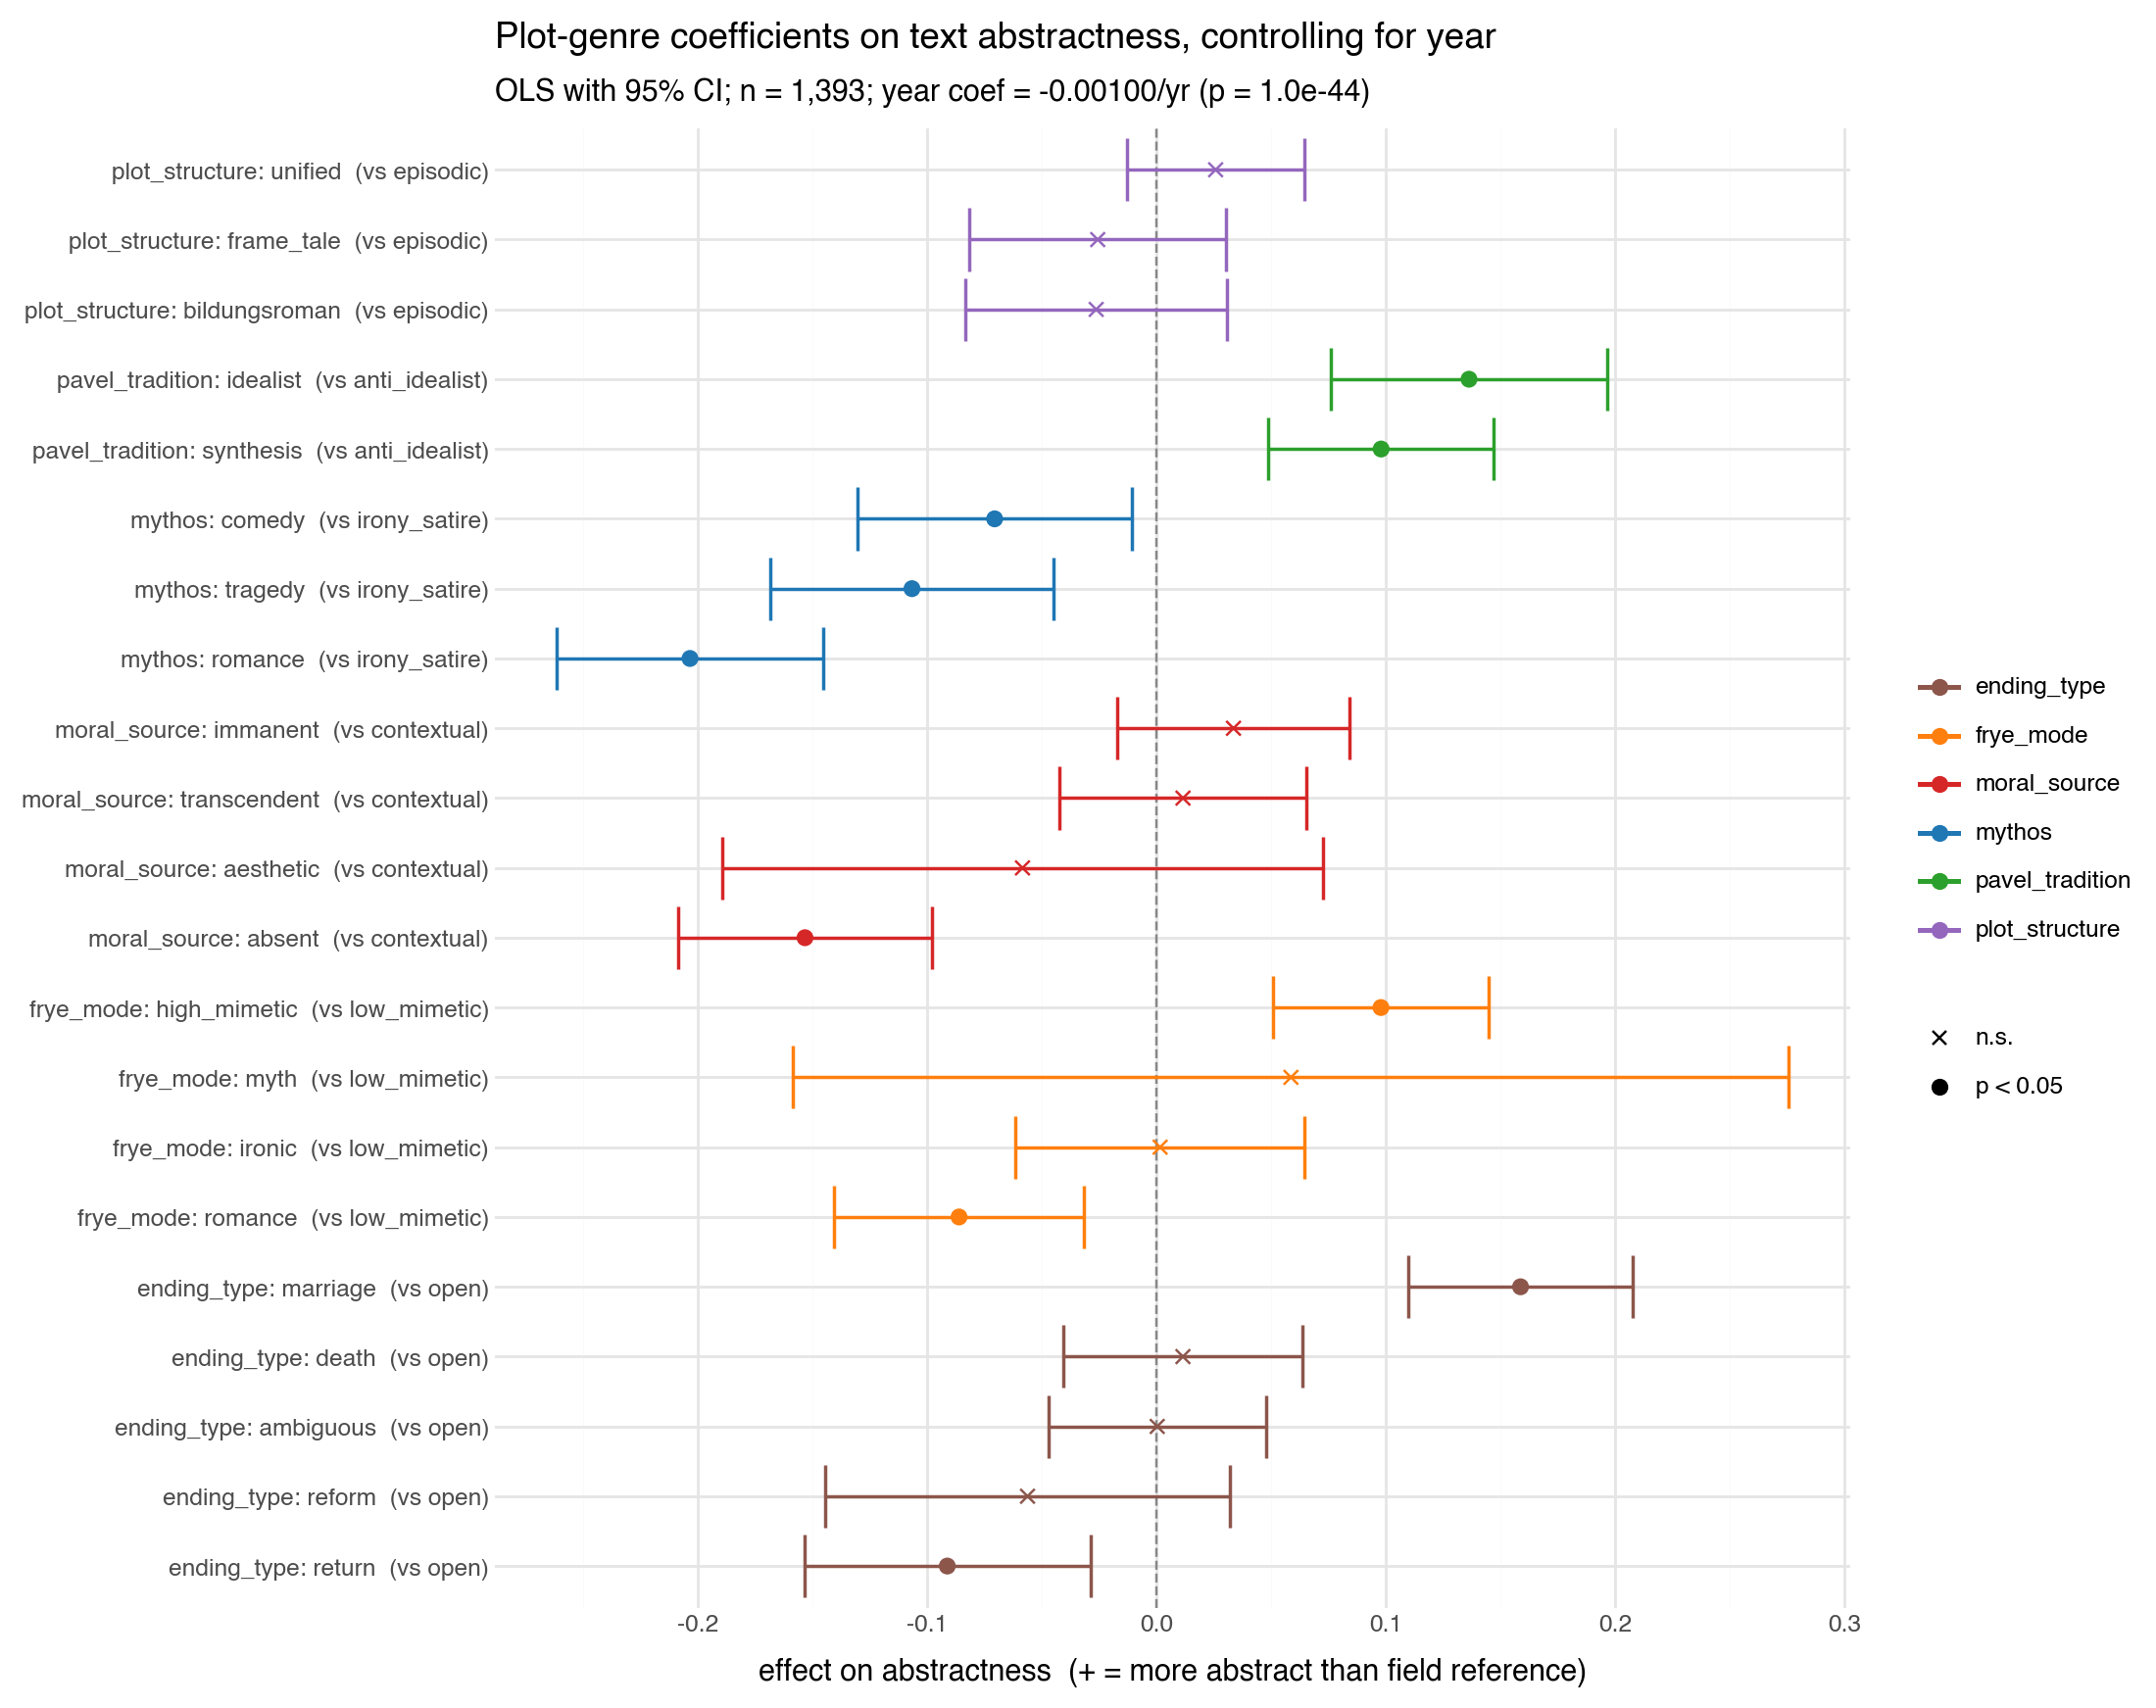

In [9]:
import statsmodels.api as sm

# Combined model: year + all 6 fields' dummies. Coefs interpretable as "effect
# of being in this category vs. the field's reference category, controlling
# for year and all other fields."
X_full = np.hstack([X_year, X_all])
X_full_const = sm.add_constant(X_full)
ols = sm.OLS(y, X_full_const).fit()

# Recover names: const, year, then dummies in field-then-category order.
dummy_cols = []
field_of = {}
for f in FIELDS:
    dum, ref, _ = make_dummies(f)
    for col in dum.columns:
        cat = col[len(f) + 1:]  # strip "field_" prefix
        dummy_cols.append((f, cat, ref))

coefs = ols.params[2:]
ses = ols.bse[2:]
pvals = ols.pvalues[2:]
records = []
for (field, cat, ref), b, s, p in zip(dummy_cols, coefs, ses, pvals):
    records.append({
        'field': field,
        'category': cat,
        'label': f'{field}: {cat}  (vs {ref})',
        'coef': b, 'se': s, 'p': p,
        'lo': b - 1.96 * s, 'hi': b + 1.96 * s,
        'signif': p < 0.05,
    })
coef_df = pd.DataFrame(records).sort_values(['field', 'coef'])
coef_df['label'] = pd.Categorical(coef_df['label'],
                                  categories=coef_df['label'].tolist(), ordered=True)

print(f'Year coef: {ols.params[1]:+.5f} per year (t = {ols.tvalues[1]:.2f}, p = {ols.pvalues[1]:.2e})')
print()
print('Plot-genre coefficients (effect on abstractness after detrending year):')
print(coef_df[['field', 'category', 'coef', 'se', 'p', 'signif']].to_string(index=False))

field_palette = {
    'mythos':          '#1f77b4',
    'frye_mode':       '#ff7f0e',
    'pavel_tradition': '#2ca02c',
    'moral_source':    '#d62728',
    'plot_structure':  '#9467bd',
    'ending_type':     '#8c564b',
}

p_coef_pg = (p9.ggplot(coef_df, p9.aes(x='coef', y='label', color='field'))
             + p9.geom_vline(xintercept=0, linetype='dashed', color='#888888')
             + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.7)
             + p9.geom_point(p9.aes(shape='signif'), size=2.5)
             + p9.scale_color_manual(values=field_palette)
             + p9.scale_shape_manual(values={True: 'o', False: 'x'},
                                     labels={True: 'p < 0.05', False: 'n.s.'})
             + p9.labs(
                 title='Plot-genre coefficients on text abstractness, controlling for year',
                 subtitle=f'OLS with 95% CI; n = {n:,}; year coef = {ols.params[1]:+.5f}/yr (p = {ols.pvalues[1]:.1e})',
                 x='effect on abstractness  (+ = more abstract than field reference)',
                 y='', color='', shape='',
             )
             + p9.theme_minimal()
             + p9.theme(figure_size=(11, max(6, 0.32 * len(coef_df) + 2)),
                        legend_position='right'))

out = os.path.join(DROPBOX_FIGS, 'plot_genre_abstractness_coefficients.png')
p_coef_pg.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_coef_pg